In [6]:
import pandas as pd
import torch
import os
import gc
import json
from tqdm.auto import tqdm
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from datasets import load_dataset

In [2]:
model_id = "Qwen/Qwen2-VL-2B-Instruct"
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# from transformers import BitsAndBytesConfig
# import torch

# model_id = "Qwen/Qwen2-VL-7B-Instruct"
# processor = AutoProcessor.from_pretrained(model_id)

# # Magia kompresji do 4-bitów
# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.bfloat16
# )

# print("Ładowanie modelu 7B w oszczędnym trybie 4-bit...")
# model = Qwen2VLForConditionalGeneration.from_pretrained(
#     model_id, 
#     quantization_config=quantization_config,
#     device_map="auto"
# )

preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

In [3]:
loaded_datasets = {}

def get_dataset_for_file(file_path):
    file_name = os.path.basename(file_path).lower()
    if "caltech" in file_name:
        dataset_name = "Caltech101"
        if dataset_name not in loaded_datasets:
            loaded_datasets[dataset_name] = load_dataset("flwrlabs/caltech101", split="train")
        return loaded_datasets[dataset_name], dataset_name
    elif "imagenet" in file_name:
        dataset_name = "ImageNet"
        if dataset_name not in loaded_datasets:
            loaded_datasets[dataset_name] = load_dataset("imagenet-1k", split="validation")
        return loaded_datasets[dataset_name], dataset_name
    else:
        raise ValueError(f"Unknown dataset for file: {file_name}")

def analyze_multiple_files(files_list, prompt_text, output_csv, batch_size=4):
    all_dataframes = []
    
    for file_path in files_list:
        df_temp = pd.read_csv(file_path, sep=';', index_col=0)
        _, dataset_name = get_dataset_for_file(file_path)
        
        df_temp['source_file'] = os.path.basename(file_path)
        df_temp['dataset_name'] = dataset_name
        all_dataframes.append(df_temp)
        
    master_df = pd.concat(all_dataframes, ignore_index=True)

    if os.path.exists(output_csv):
        os.remove(output_csv)

    for i in tqdm(range(0, len(master_df), batch_size)):
        batch_df = master_df.iloc[i : i + batch_size]
        
        batch_messages = []
        images_flat = []
        results = []

        for _, row in batch_df.iterrows():
            id_1 = int(row['id_1'])
            id_2 = int(row['id_2'])
            dataset_name = row['dataset_name']
            target_dataset = loaded_datasets[dataset_name]

            img1 = target_dataset[id_1]['image'].convert('RGB')
            img2 = target_dataset[id_2]['image'].convert('RGB')
            
            images_flat.extend([img1, img2])

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": img1},
                        {"type": "image", "image": img2},
                        {"type": "text", "text": prompt_text},
                    ],
                }
            ]
            batch_messages.append(messages)

        texts = [
            processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True) 
            for msg in batch_messages
        ]

        inputs = processor(
            text=texts, 
            images=images_flat, 
            padding=True, 
            return_tensors="pt"
        ).to("cuda")

        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=512)
            
        generated_ids_trimmed = [
            out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        
        responses = processor.batch_decode(
            generated_ids_trimmed, 
            skip_special_tokens=True, 
            clean_up_tokenization_spaces=False
        )

        for j in range(len(batch_df)):
            original_row_data = batch_df.iloc[j].to_dict()
            
            raw_response = responses[j].strip()
            if raw_response.startswith("```json"):
                raw_response = raw_response[7:]
            if raw_response.startswith("```"):
                raw_response = raw_response[3:]
            if raw_response.endswith("```"):
                raw_response = raw_response[:-3]
                
            raw_response = raw_response.strip()

            # categories_keys = [
            #     "Object_Missing", "Color_Difference", "Background_Change", 
            #     "Perspective_Angle", "Human_Presence", "Text_Or_Branding", "Quantity_Or_Arrangement"
            # ]

            categories_keys = [
                "Orientation_And_Direction", "Presence_Of_Features", "State_And_Condition", 
                "Quantity_And_Count", "Positional_Context", "Color_And_Appearance", 
                "Structural_Characteristics", "Text", "Viewpoint_Perspective"
            ]

            try:
                parsed_json = json.loads(raw_response)
                for key in categories_keys:
                    if key in parsed_json and parsed_json[key] is not None:
                        parsed_json[key] = int(parsed_json[key])
            except json.JSONDecodeError:
                parsed_json = {key: None for key in categories_keys}
                parsed_json["Explanation"] = raw_response

            merged_row = {**original_row_data, **parsed_json}
            results.append(merged_row)
            
        temp_df = pd.DataFrame(results)
        temp_df.to_csv(output_csv, mode='a', header=not os.path.exists(output_csv), index=False)
        
        del inputs, generated_ids, generated_ids_trimmed, responses, texts, batch_messages, images_flat, temp_df, results
        torch.cuda.empty_cache()
        gc.collect()

    return pd.read_csv(output_csv)

files = [
    "C:\\Users\\alapr\\Downloads\\clip_caltech_blind_spots.csv",
    "C:\\Users\\alapr\\Downloads\\dino_caltech_blind_spots.csv",
    "C:\\Users\\alapr\\Downloads\\siglip2_caltech_blind_spots.csv",
    "C:\\Users\\alapr\\Downloads\\siglip_caltech_blind_spots.csv"
    # "/content/vision_blindspots/clip_caltech_blind_spots.csv",
    # "/content/vision_blindspots/dino_caltech_blind_spots.csv",
    # "/content/vision_blindspots/siglip2_caltech_blind_spots.csv",
    # "/content/vision_blindspots/siglip_caltech_blind_spots.csv"
]

output_master_file = "C:\\Users\\alapr\\Downloads\\caltech_differences_by_qwen.csv"

# model_prompt = """Analyze these two images carefully. You must respond ONLY with a valid JSON object. Do not include any markdown formatting, explanations, or text outside the JSON block.

# Step 1: Write a detailed explanation of the exact differences between the two images.
# Step 2: Based on your explanation, determine if the differences fall into the categories below.

# Use exactly this JSON structure, replacing 'null' with integer 1 (for yes) or 0 (for no):
# {
#   "Explanation": "Provide a detailed paragraph here describing the exact differences between the two images FIRST.",
#   "Object_Missing": null,
#   "Color_Difference": null,
#   "Background_Change": null,
#   "Perspective_Angle": null,
#   "Human_Presence": null,
#   "Text_Or_Branding": null,
#   "Quantity_Or_Arrangement": null
# }"""

#wcześniejszy prompt na innych kategoriach plik o nazwie clatech_diff_description.csv



#inny prompt zmienione kategorie, plik caltech_differences_by_qwen
model_prompt = model_prompt = """Analyze these two images carefully. You must respond ONLY with a valid JSON object. Do not include any markdown formatting, explanations, or text outside the JSON block.

Step 1: Write a detailed explanation of the exact differences between the two images.
Step 2: Based on your explanation, determine if the differences fall into the specific categories below.

Use exactly this JSON structure, replacing 'null' with integer 1 (for yes, there is a difference in this category) or 0 (for no difference):
{
  "Explanation": "Provide a detailed paragraph here describing the exact differences between the two images FIRST.",
  "Orientation_And_Direction": null,  // Is an object facing a different way, flipped, or rotated?
  "Presence_Of_Features": null,       // Is a specific part or small detail added or missing (e.g., glasses, a handle, a leaf)?
  "State_And_Condition": null,        // Is the object in a different state (e.g., open/closed, broken/whole, wet/dry, cooked/raw)?
  "Quantity_And_Count": null,         // Is the number of objects different?
  "Positional_Context": null,         // Are objects placed differently relative to each other or the background?
  "Color_And_Appearance": null,       // Are there changes in colors, lighting, or overall vibrancy?
  "Structural_Characteristics": null, // Is the core shape, material, or physical build of the object fundamentally different?
  "Text": null,                       // Are there differences in written words, numbers, or logos?
  "Viewpoint_Perspective": null       // Is the camera angle, zoom level, or framing different?
}"""

final_df = analyze_multiple_files(files, model_prompt, output_master_file, batch_size=4)
print(final_df.head())

data/train-00000-of-00001.parquet:   0%|          | 0.00/121M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8677 [00:00<?, ? examples/s]

  0%|          | 0/188 [00:00<?, ?it/s]

   id_1  id_2 base_name  score_base ref_1_name  score_ref_1 ref_2_name  \
0    20   465      CLIP    0.961227     SigLIP     0.425818       DINO   
1    55  7297      CLIP    0.987392     SigLIP     0.586700       DINO   
2    84  8550      CLIP    0.965167     SigLIP     0.366609       DINO   
3    84  4583      CLIP    0.963342     SigLIP     0.417315       DINO   
4   116  5039      CLIP    0.957302     SigLIP     0.139836       DINO   

   score_ref_2                   source_file dataset_name  \
0     0.990587  clip_caltech_blind_spots.csv   Caltech101   
1     0.990598  clip_caltech_blind_spots.csv   Caltech101   
2     0.748084  clip_caltech_blind_spots.csv   Caltech101   
3     0.788334  clip_caltech_blind_spots.csv   Caltech101   
4     0.982948  clip_caltech_blind_spots.csv   Caltech101   

                                         Explanation  \
0  The two images appear to be identical. There a...   
1  The two images depict the same jaguar, but the...   
2  The two images de

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Podsumowanie znormalizowane (w %):
           Orientation_And_Direction  Presence_Of_Features  \
base_name                                                    
CLIP                           25.26                 10.82   
DINO                           60.67                  7.43   
SigLIP                         33.33                  0.00   
SigLIP2                        22.46                 11.59   

           State_And_Condition  Quantity_And_Count  Positional_Context  \
base_name                                                                
CLIP                      9.79                9.79               12.37   
DINO                      7.19                6.95               11.27   
SigLIP                    0.00                0.00                0.00   
SigLIP2                  10.87               10.87               13.77   

           Color_And_Appearance  Structural_Characteristics  Text  \
base_name                                                           
CLIP     

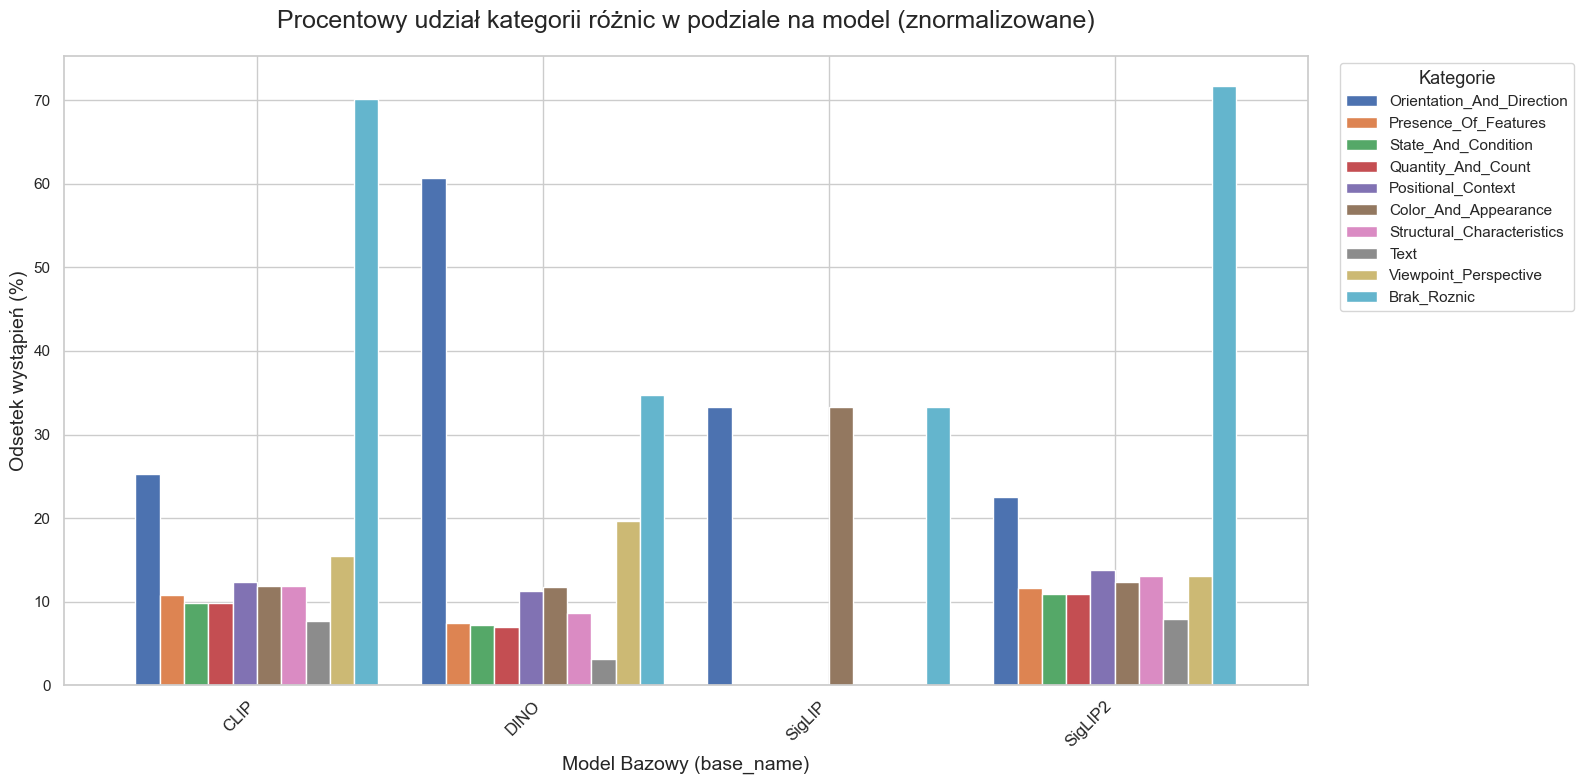

In [4]:


# 1. Wczytanie danych
plik_csv = "C:\\Users\\alapr\\Downloads\\caltech_differences_by_qwen.csv" 
df = pd.read_csv(plik_csv)
final_df = df.copy()  # Tworzymy kopię, aby zachować oryginalne dane bez zmian

# 2. Definicja kolumn z kategoriami
# kategorie = [
#     "Object_Missing", "Color_Difference", "Background_Change", 
#     "Perspective_Angle", "Human_Presence", "Text_Or_Branding", "Quantity_Or_Arrangement"
# ]
kategorie = [
                "Orientation_And_Direction", "Presence_Of_Features", "State_And_Condition", 
                "Quantity_And_Count", "Positional_Context", "Color_And_Appearance", 
                "Structural_Characteristics", "Text", "Viewpoint_Perspective"
            ]

# Upewniamy się, że kolumny są traktowane jako liczby (zabezpieczenie przed błędami)
for kat in kategorie:
    df[kat] = pd.to_numeric(df[kat], errors='coerce').fillna(0).astype(int)

# 3. Wykrywanie "wszystkich zer" (Brak różnic)
df['Brak_Roznic'] = (df[kategorie].sum(axis=1) == 0).astype(int)

wszystkie_kategorie = kategorie + ['Brak_Roznic']

# 4. Agregacja i Normalizacja
# Najpierw liczymy absolutną sumę wystąpień dla każdego modelu
grupowane_sumy = df.groupby('base_name')[wszystkie_kategorie].sum()

# Następnie liczymy, ile łącznie par zdjęć (wierszy) przeanalizował dany model
liczba_par_per_model = df.groupby('base_name').size()

# Dzielimy sumy przez łączną liczbę par i mnożymy przez 100, aby uzyskać procenty (%)
grupowane_znormalizowane = grupowane_sumy.div(liczba_par_per_model, axis=0) * 100

print("Podsumowanie znormalizowane (w %):")
print(grupowane_znormalizowane.round(2)) # Zaokrąglamy do 2 miejsc po przecinku dla czytelności

# 5. Rysowanie wykresu
sns.set_theme(style="whitegrid")

# Rysujemy znormalizowane dane
ax = grupowane_znormalizowane.plot(kind='bar', figsize=(16, 8), width=0.85, stacked=False)

# Upiększanie wykresu
plt.title('Procentowy udział kategorii różnic w podziale na model (znormalizowane)', fontsize=18, pad=20)
plt.xlabel('Model Bazowy (base_name)', fontsize=14)
# Zmiana etykiety osi Y na procenty
plt.ylabel('Odsetek wystąpień (%)', fontsize=14)

# Obrócenie podpisów na osi X
plt.xticks(rotation=45, ha='right', fontsize=12)

# Przeniesienie legendy
plt.legend(title='Kategorie', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=13)

# Dostosowanie marginesów i wyświetlenie
plt.tight_layout()
plt.show()

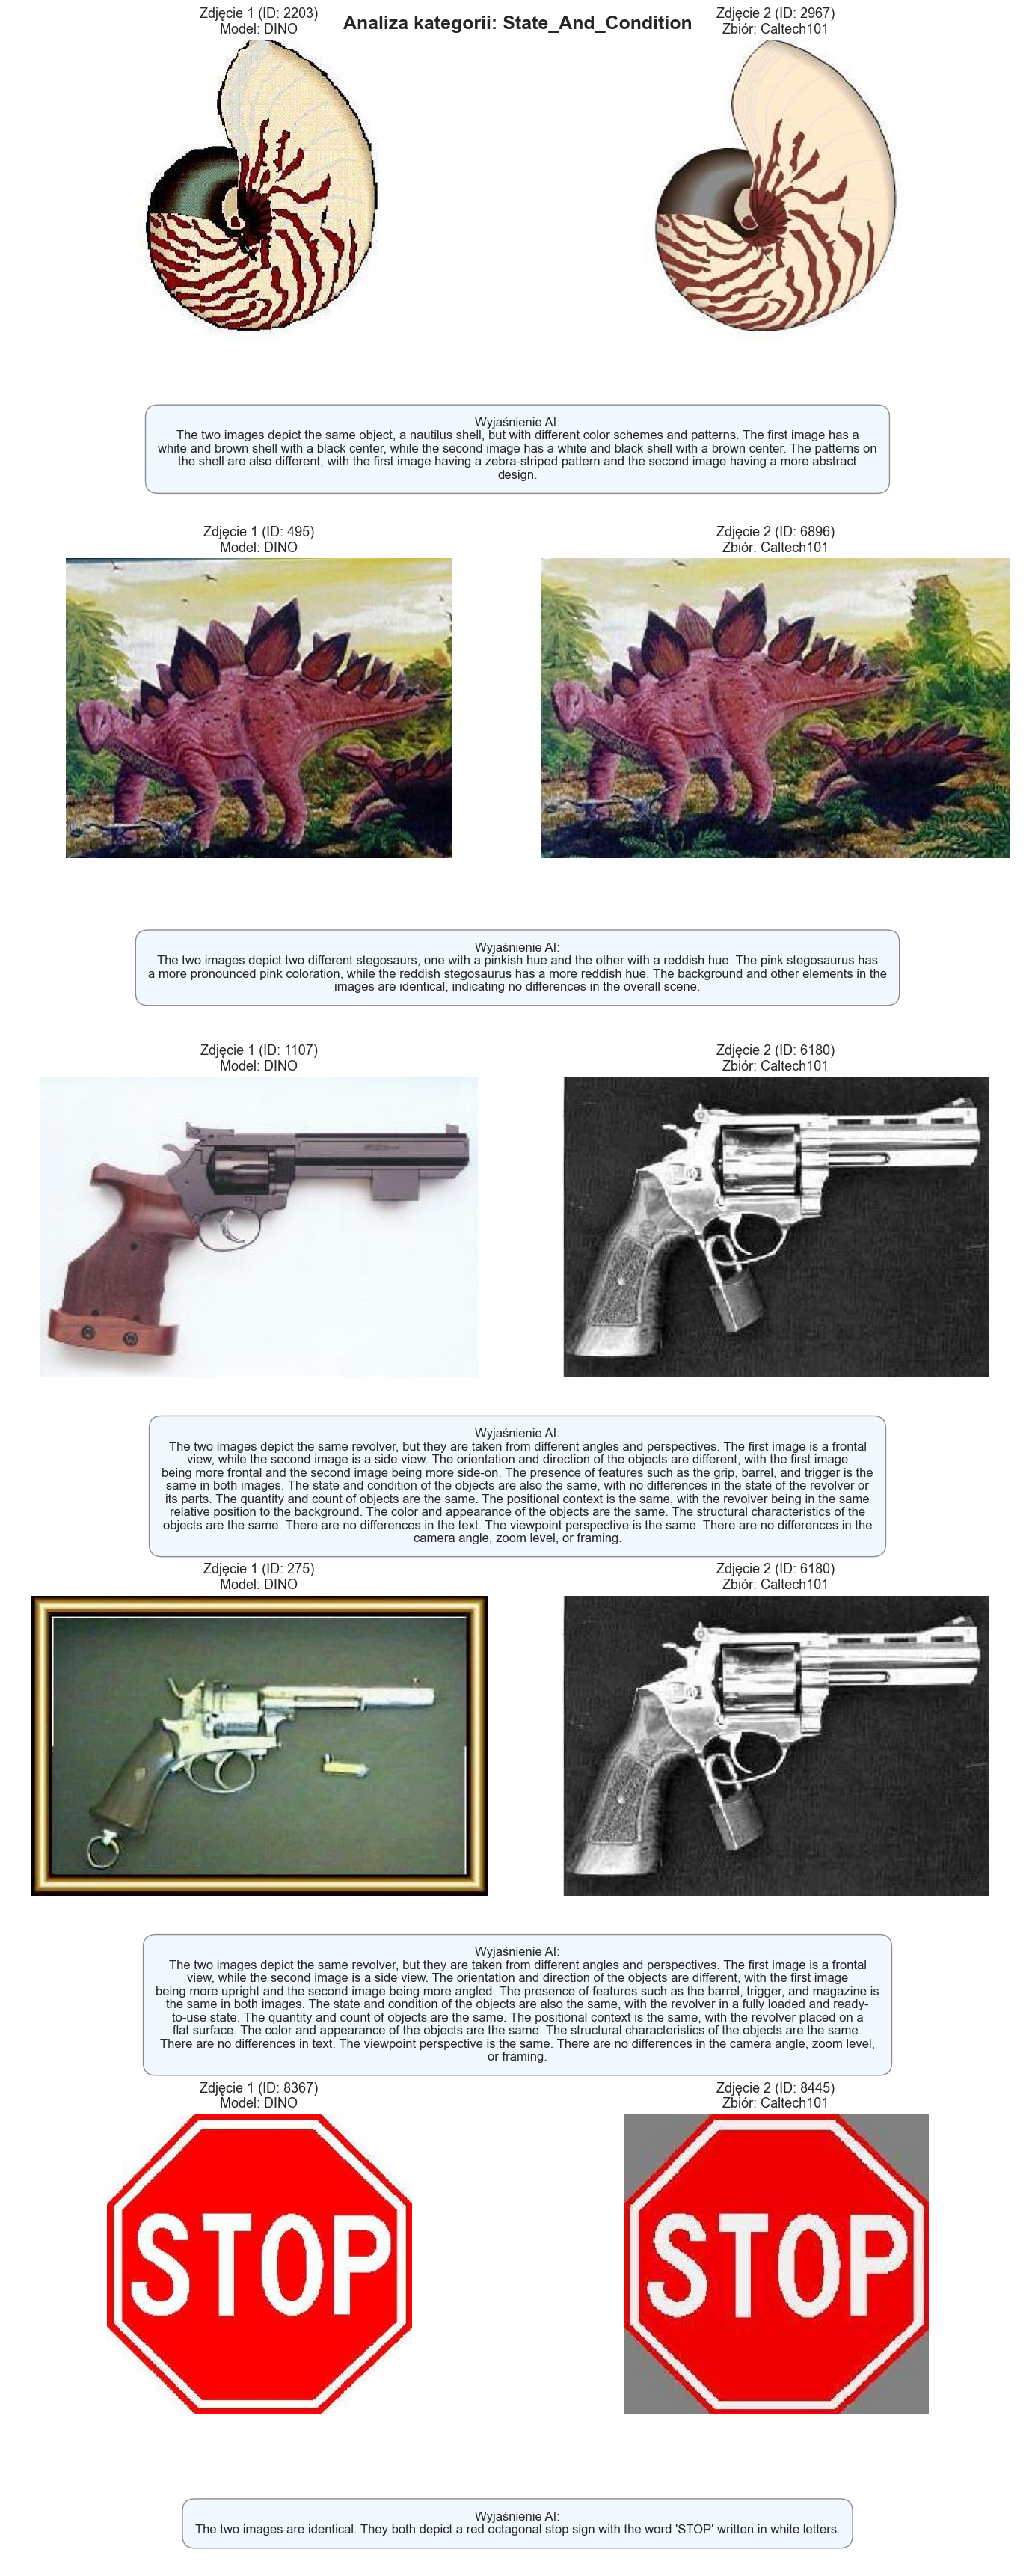

In [11]:
import matplotlib.pyplot as plt
import textwrap
import matplotlib.gridspec as gridspec
from datasets import load_dataset
loaded_datasets = {}
loaded_datasets["Caltech101"] = load_dataset("flwrlabs/caltech101", split="train")
# Jeśli masz też obrazy z ImageNet w CSV:
# loaded_datasets["ImageNet"] = load_dataset("imagenet-1k", split="validation")

def wyswietl_pary_dla_kategorii(df, kategoria, wybrane_modele=None, liczba_par=3):
    # 1. Filtrowanie po wybranych modelach bazowych (base_name)
    df_filtered = df.copy()
    if wybrane_modele:
        # Jeśli podano pojedynczy string (np. 'CLIP-ViT-B'), zamieniamy na listę
        if isinstance(wybrane_modele, str):
            wybrane_modele = [wybrane_modele]
        
        # Zostawiamy tylko te wiersze, gdzie base_name jest na naszej liście
        df_filtered = df_filtered[df_filtered['base_name'].isin(wybrane_modele)]
        
        if df_filtered.empty:
            print(f"Brak danych dla modeli: {wybrane_modele}")
            return

    # 2. Filtrujemy po wybranej kategorii
    dane_kategorii = df_filtered[df_filtered[kategoria] == 1]
    
    if dane_kategorii.empty:
        print(f"Brak par zdjęć dla kategorii: {kategoria} (dla wybranych modeli)")
        return
        
    probka = dane_kategorii.sample(n=min(liczba_par, len(dane_kategorii)))
    
    # 3. Ustawienie siatki (GridSpec) - gwarantuje brak nakładania się elementów
    # Tworzymy 2 wiersze na każdą parę: jeden na zdjęcia, drugi na opis
    fig = plt.figure(figsize=(14, 7 * len(probka)))
    gs = gridspec.GridSpec(len(probka) * 2, 2, height_ratios=[5, 1.5] * len(probka))
    
    for i, (_, row) in enumerate(probka.iterrows()):
        id_1 = int(row['id_1'])
        id_2 = int(row['id_2'])
        dataset_name = row['dataset_name']
        model_name = row.get('base_name', 'Nieznany model')
        
        # Pobieranie zdjęć (zakładamy, że loaded_datasets jest nadal w pamięci)
        target_dataset = loaded_datasets[dataset_name]
        img1 = target_dataset[id_1]['image'].convert('RGB')
        img2 = target_dataset[id_2]['image'].convert('RGB')
        
        # Oś dla pierwszego zdjęcia (lewa kolumna)
        ax1 = fig.add_subplot(gs[i*2, 0])
        ax1.imshow(img1)
        ax1.set_title(f"Zdjęcie 1 (ID: {id_1})\nModel: {model_name}", fontsize=13)
        ax1.axis('off')
        
        # Oś dla drugiego zdjęcia (prawa kolumna)
        ax2 = fig.add_subplot(gs[i*2, 1])
        ax2.imshow(img2)
        ax2.set_title(f"Zdjęcie 2 (ID: {id_2})\nZbiór: {dataset_name}", fontsize=13)
        ax2.axis('off')
        
        # Oś dla tekstu (zajmuje obie kolumny w rzędzie poniżej zdjęć)
        ax_text = fig.add_subplot(gs[i*2 + 1, :])
        ax_text.axis('off') # Ukrywamy ramki wykresu dla osi tekstowej
        
        wyjasnienie = str(row.get('Explanation', 'Brak opisu'))
        # Zawijamy tekst na 130 znaków, żeby był szeroki, ale nie wychodził poza ekran
        zawiniety_tekst = textwrap.fill(wyjasnienie, width=130) 
        
        # Wypisujemy tekst idealnie na środku zarezerwowanego obszaru
        ax_text.text(0.5, 0.5, f"Wyjaśnienie AI:\n{zawiniety_tekst}", 
                     ha='center', va='center', fontsize=12, 
                     bbox=dict(facecolor='#f0f8ff', alpha=0.9, edgecolor='gray', boxstyle='round,pad=1'))

    plt.suptitle(f"Analiza kategorii: {kategoria}", fontsize=18, y=0.98, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- PRZYKŁADY UŻYCIA ---

# 1. Wyświetl dla konkretnego modelu:
wyswietl_pary_dla_kategorii(
    final_df, 
    kategoria="State_And_Condition", 
    wybrane_modele="DINO", # Podmień na właściwą nazwę z kolumny base_name!
    liczba_par=5
)

# 2. Wyświetl dla listy kilku modeli:
# wyswietl_pary_dla_kategorii(
#     final_df, 
#     kategoria="Color_Difference", 
#     wybrane_modele=["model_A", "model_B"], 
#     liczba_par=3
# )